In [27]:
from util import *
plt.rcParams['font.family'] = 'Noto Sans'

%reload_ext autoreload
%autoreload 2

In [28]:
figPath = "../plots/control_designs/"

dirs = [a for a in getDirs(os.path.join(dataPath, 'control'), sstr='nVDCC') if "ISI_20" in a]
dirs.sort(key=natural_keys)
control_dirs = np.array(dirs)

## Get a list of designs in each category 
designs_in_categories = get_designs_in_categories(control_dirs)

for i,d in enumerate(control_dirs): print(i, d)

0 nVDCC_1_dVAZ_60_nAZ_33_RRP_55_ISI_20_nAP_10
1 nVDCC_1_dVAZ_60_nAZ_33_RRP_60_ISI_20_nAP_10
2 nVDCC_2_dVAZ_60_nAZ_7_RRP_60_ISI_20_nAP_10
3 nVDCC_2_dVAZ_60_nAZ_9_RRP_55_ISI_20_nAP_10
4 nVDCC_2_dVAZ_60_nAZ_9_RRP_60_ISI_20_nAP_10
5 nVDCC_2_dVAZ_60_nAZ_11_RRP_40_ISI_20_nAP_10
6 nVDCC_2_dVAZ_60_nAZ_11_RRP_45_ISI_20_nAP_10
7 nVDCC_2_dVAZ_60_nAZ_11_RRP_50_ISI_20_nAP_10
8 nVDCC_2_dVAZ_60_nAZ_13_RRP_35_ISI_20_nAP_10
9 nVDCC_2_dVAZ_60_nAZ_13_RRP_40_ISI_20_nAP_10
10 nVDCC_2_dVAZ_60_nAZ_13_RRP_45_ISI_20_nAP_10
11 nVDCC_2_dVAZ_60_nAZ_13_RRP_50_ISI_20_nAP_10
12 nVDCC_2_dVAZ_60_nAZ_15_RRP_30_ISI_20_nAP_10
13 nVDCC_2_dVAZ_60_nAZ_15_RRP_35_ISI_20_nAP_10
14 nVDCC_2_dVAZ_60_nAZ_17_RRP_30_ISI_20_nAP_10
15 nVDCC_2_dVAZ_60_nAZ_19_RRP_30_ISI_20_nAP_10
16 nVDCC_2_dVAZ_60_nAZ_21_RRP_20_ISI_20_nAP_10
17 nVDCC_2_dVAZ_60_nAZ_21_RRP_25_ISI_20_nAP_10
18 nVDCC_2_dVAZ_60_nAZ_23_RRP_20_ISI_20_nAP_10
19 nVDCC_2_dVAZ_60_nAZ_23_RRP_25_ISI_20_nAP_10
20 nVDCC_2_dVAZ_60_nAZ_25_RRP_20_ISI_20_nAP_10
21 nVDCC_2_dVAZ_60_nAZ_27_

### Load category info
Create category_info.pk file if it doesn't exist. Update it if needed

In [29]:
## If True, recreate category_info.pk. Override if category_info exists.
override = False

category_info_path = os.path.join(dataPath, 'control_eachCa/category_info.pk')
if os.path.exists(category_info_path) and not override:
    with open(category_info_path, "rb") as infile:
        category_info = pk.load(infile)
        
else:
    # get info (Pr, nRel, MVU, facilitation, Ca peak, residual Ca, syt) of each category
    category_info = np.empty([3,3,3,3], dtype=object)
    for nv, dv, naz, rrp in tq(list(product(range(3), repeat=4))):
        category_info[nv, dv, naz, rrp] = {'n_designs': len(designs_in_categories[nv, dv, naz, rrp])}

        # get representative designs (max and median facilitation)
        category_info[nv, dv, naz, rrp].update(get_rep_design(designs_in_categories[nv, dv, naz, rrp]))

        # Info related to vesicle release
        category_info[nv, dv, naz, rrp].update(get_release_info(designs_in_categories[nv, dv, naz, rrp]))

        # Calcium info
        category_info[nv, dv, naz, rrp].update(get_calcium_info(designs_in_categories[nv, dv, naz, rrp]))

        # Info about synaptotagmin
        category_info[nv, dv, naz, rrp].update(get_synaptotagmin_info(designs_in_categories[nv, dv, naz, rrp]))

        # Info about calcium overlap
        category_info[nv, dv, naz, rrp].update(get_ca_overlap_info(designs_in_categories[nv, dv, naz, rrp]))

    with open(category_info_path, "wb") as infile:
        pk.dump(category_info, infile)
    
    print(category_info[0,0,0,0].keys(), '\n\n', category_info[0,0,0,0])

## If True, update category_info.pk with new design info
update = False
if update:
    for nv, dv, naz, rrp in tq(list(product(range(3), repeat=4))):
        if len(designs_in_categories[nv, dv, naz, rrp]) >= 4:
            # Info about synaptotagmin
            category_info[nv, dv, naz, rrp].update(get_synaptotagmin_info(designs_in_categories[nv, dv, naz, rrp]))

    with open(category_info_path, "wb") as infile:
        pk.dump(category_info, infile)

    print(category_info[0,0,0,0])
    print(category_info[2,2,2,1])

## Plot

- Ca peak
- Residual Ca
- calcium overlap
- synaptotagmin

In [30]:
for k in list(category_info[0,0,0,0]): print(k)

n_designs
rep_design_max
rep_design_median
pr
rel
mvu
facil
avg_ca_peak
avg_res_ca
avg_ca_syt7_peak
avg_ca_syt1_peak
rep_design_min
avg_peak_overlap
avg_basal_overlap


### Peak and residual calcium (Supplementary figure) 

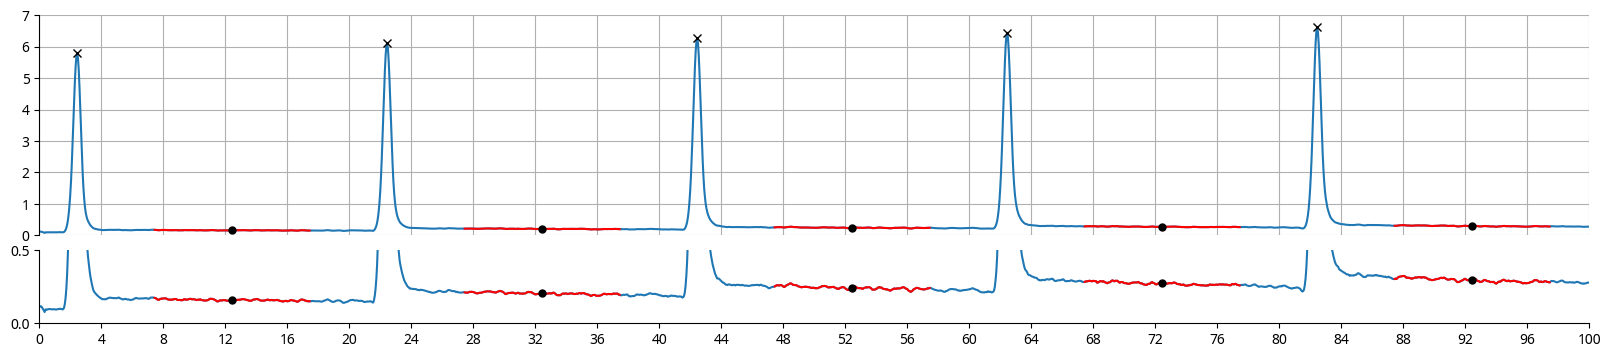

In [31]:
design = 'nVDCC_11_dVAZ_180_nAZ_13_RRP_20_ISI_20_nAP_10'
naz  = int(getSimInfo(design, 'nAZ', skip=0))

## Read data from 'CaConc.dat' of the design
data = pd.read_csv(os.path.join(dataPath, 'control', design, 'CaConc.dat'), 
                    usecols=range(naz+1), sep='\t')
data['mean'] = np.mean(data.iloc[:,1:], axis=1)
data['Seconds'] *= 1000 # convert to ms
# print(design, '\n', data)

## Detect peaks and ensure all 10 peaks are detected
idx = detect_peaks(data['mean'], mph=1, mpd=200, threshold=0, edge='rising', show=False)
assert len(idx) == 10, f'Peak detecction failed for design {design}'

ca_peak = [data.loc[id,'mean'] for id in idx]
ca_res = [np.mean(data.loc[id+100:id+300,'mean']) for id in idx]
# print(ca_peak, '\n', ca_res)

fig, ax = plt.subplots(2,1, figsize=(20,4), sharex=True,
                        gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0.1)
ax[0].plot('Seconds', 'mean', data=data)
ax[1].plot('Seconds', 'mean', data=data)

for id in idx:
    ax[0].plot('Seconds', 'mean', data=data.loc[id+100:id+300,:], color='red')
    ax[0].plot('Seconds', 'mean', data=data.loc[id,:], marker='x', color='black')
    ax[1].plot('Seconds', 'mean', data=data.loc[id+100:id+300,:], color='red')

ax[1].plot(data.loc[idx+200,['Seconds']], ca_res, marker='o', markersize=5, 
           color='black', linestyle='None')
ax[0].plot(data.loc[idx+200,['Seconds']], ca_res, marker='o', markersize=5, 
           color='black', linestyle='None')

ax[0].set_ylim(0,7)
ax[1].set_ylim(0,0.5)
ax[0].spines[['bottom']].set_visible(False)
ax[0].tick_params(axis='x', which='both', bottom=False, top=False)
ax[0].grid()
ax[1].set_xticks(range(0,201,4))
ax[1].set_yticks([0,0.5])
for axis in ax.ravel():
    axis.spines[['right', 'top']].set_visible(False)
    axis.set_xlim(0,100)
plt.show()

fig.savefig(os.path.join(figPath, f'supp_Ca.svg'), dpi=300, 
            bbox_inches='tight', transparent=True)

In [32]:
figsize_4d = (5,4.1)

ticklabelsize_4d = 8
labelsize_4d = 10
sublabelsize_4d = 8
textsize_4d = 8

cases = ['Low', 'Mid', 'High']

### Calcium Peak

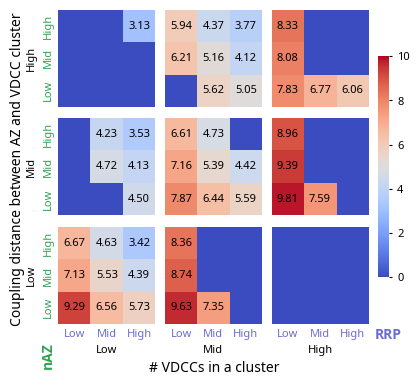

In [33]:
key = 'avg_ca_peak'

cat_plot = np.zeros(category_info.shape)
for nv, dv, naz, rrp in product(range(3), repeat=4):
    try:
        cat_plot[nv, dv, naz, rrp] = category_info[nv, dv, naz, rrp][key][0][-1]
    except KeyError:
        cat_plot[nv, dv, naz, rrp] = 0
        
fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=figsize_4d)
fig.subplots_adjust(wspace=0.1, hspace=0.1)

for axis in ax[-1,:]:
    axis.set_xticks(range(3))
    axis.set_xticklabels(cases, color=cpdark[5], fontsize=ticklabelsize_4d)

for axis in ax[:,0]:
    axis.set_yticks(range(3))
    axis.set_yticklabels(cases, color=cpdark[2], fontsize=ticklabelsize_4d,
                         rotation=90, ha="right", va="center")

for nv, dv in product(range(3), range(3)):
    ax[nv][dv].tick_params(axis=u'both', which=u'both',length=0)
    
    imdata = cat_plot[dv, 2-nv]
    im = ax[nv][dv].imshow(
        imdata, 
        vmin=np.floor(np.min(cat_plot)) if np.min(cat_plot)>1 else np.min(cat_plot), 
        vmax=np.ceil(np.max(cat_plot)) if np.max(cat_plot)>1 else np.max(cat_plot),
        cmap='coolwarm', 
        origin='lower'
    )
    
    for i in range(3):
        for j in range(3):
            if imdata[i, j] > 0.001:
                text = ax[nv][dv].text(j, i, f'{imdata[i, j]:0.2f}', fontsize=textsize_4d,
                                       ha="center", va="center", color="black")
    if nv==2:
        ax[nv][dv].set_xlabel(cases[dv], fontsize=sublabelsize_4d)
    if dv==0:
        ax[nv][dv].set_ylabel(cases[2-nv], fontsize=sublabelsize_4d)
       
    ax[nv][dv].spines[["bottom","top","right","left"]].set_visible(False)
    
ax[-1,0].text(-1.05, -1.8, 'nAZ', size=labelsize_4d, rotation=90, color=cpdark[2], fontweight='bold')
ax[-1,-1].text(2.7, -0.96, 'RRP', size=labelsize_4d, color=cpdark[5], fontweight='bold')
ax[-1,1].text(-1, -2, '# VDCCs in a cluster', size=labelsize_4d, color=cpdark[-1])
ax[1,0].text(-2, -3.8, 'Coupling distance between AZ and VDCC cluster', 
             size=labelsize_4d, rotation=90, color=cpdark[-1])

cb = fig.colorbar(im, ax=ax.ravel().tolist(), shrink=0.7, anchor=(-0.2,0.5))
cb.outline.set_visible(False)
cb.ax.tick_params(size=2, labelsize=ticklabelsize_4d)
plt.show()

fig.savefig(os.path.join(figPath, f'{key}_4D.svg'), dpi=300, 
            bbox_inches='tight', transparent=True)

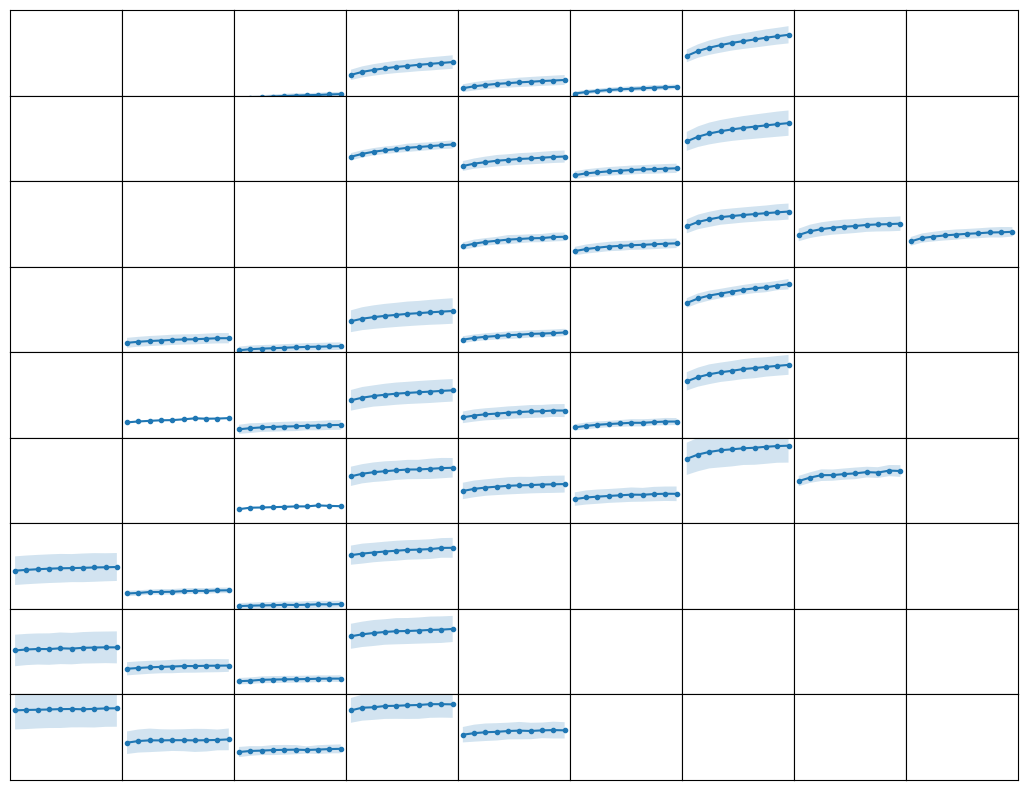

In [34]:
key = 'avg_ca_peak'
fig, ax = plt.subplots(9,9, figsize=(13,10), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0, hspace=0)

x = list(range(1,11))
for nv, dv, naz, rrp in list(product(range(3), repeat=4))[:]:
    try:
        design_y, design_std = category_info[nv, dv, naz, rrp][key]
    except KeyError:
        continue

    row = 3*(2 - dv) + (2 - naz)
    col = 3*nv + rrp
    # print(row, col)

    ax[row, col].plot(x, design_y, '.-')
    ax[row, col].fill_between(x, design_y - design_std, design_y + design_std, alpha=0.2)

    for axis in ax.ravel():
        axis.tick_params(left=False, right=False, labelleft=False,
                         labelbottom=False, bottom=False)
        axis.set_ylim(3, 10.5)

plt.show()
fig.savefig(os.path.join(figPath, f'{key}_4D_full.pdf'), dpi=300, 
          bbox_inches='tight', transparent=True) 

### Residual Calcium

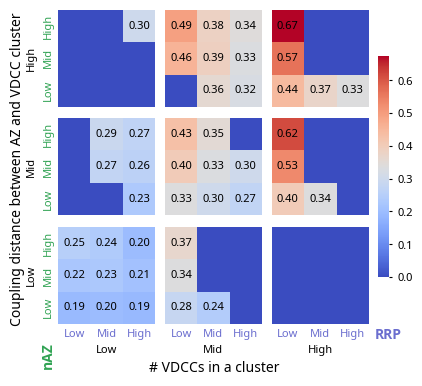

In [35]:
key = 'avg_res_ca'

cat_plot = np.zeros(category_info.shape)
for nv, dv, naz, rrp in product(range(3), repeat=4):
    try:
        cat_plot[nv, dv, naz, rrp] = category_info[nv, dv, naz, rrp][key][0][-1]
    except KeyError:
        cat_plot[nv, dv, naz, rrp] = 0

fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=figsize_4d)
fig.subplots_adjust(wspace=0.1, hspace=0.1)

for axis in ax[-1,:]:
    axis.set_xticks(range(3))
    axis.set_xticklabels(cases, color=cpdark[5], fontsize=ticklabelsize_4d)

for axis in ax[:,0]:
    axis.set_yticks(range(3))
    axis.set_yticklabels(cases, color=cpdark[2], fontsize=ticklabelsize_4d,
                         rotation=90, ha="right", va="center")
for nv, dv in product(range(3), range(3)):
    ax[nv][dv].tick_params(axis=u'both', which=u'both',length=0)
    
    imdata = cat_plot[dv, 2-nv]
    im = ax[nv][dv].imshow(
        imdata,
        vmin=np.floor(np.min(cat_plot)) if np.min(cat_plot)>1 else np.min(cat_plot), 
        vmax=np.ceil(np.max(cat_plot)) if np.max(cat_plot)>1 else np.max(cat_plot),
        cmap='coolwarm', 
        origin='lower'
    )
    
    for i in range(3):
        for j in range(3):
            if imdata[i, j] > 0.001:
                text = ax[nv][dv].text(j, i, f'{imdata[i, j]:0.2f}', fontsize=textsize_4d,
                                       ha="center", va="center", color="black")
    if nv==2:
        ax[nv][dv].set_xlabel(cases[dv], fontsize=sublabelsize_4d)
    if dv==0:
        ax[nv][dv].set_ylabel(cases[2-nv], fontsize=sublabelsize_4d)
       
    ax[nv][dv].spines[["bottom","top","right","left"]].set_visible(False)
    
ax[-1,0].text(-1.05, -1.8, 'nAZ', size=labelsize_4d, rotation=90, color=cpdark[2], fontweight='bold')
ax[-1,-1].text(2.7, -0.96, 'RRP', size=labelsize_4d, color=cpdark[5], fontweight='bold')
ax[-1,1].text(-1, -2, '# VDCCs in a cluster', size=labelsize_4d, color=cpdark[-1])
ax[1,0].text(-2, -3.8, 'Coupling distance between AZ and VDCC cluster', 
             size=labelsize_4d, rotation=90, color=cpdark[-1])

cb = fig.colorbar(im, ax=ax.ravel().tolist(), shrink=0.7, anchor=(-0.2,0.5))
cb.outline.set_visible(False)
cb.ax.tick_params(size=2, labelsize=ticklabelsize_4d)
plt.show()

fig.savefig(os.path.join(figPath, f'{key}_4D.svg'), dpi=300, 
            bbox_inches='tight', transparent=True)

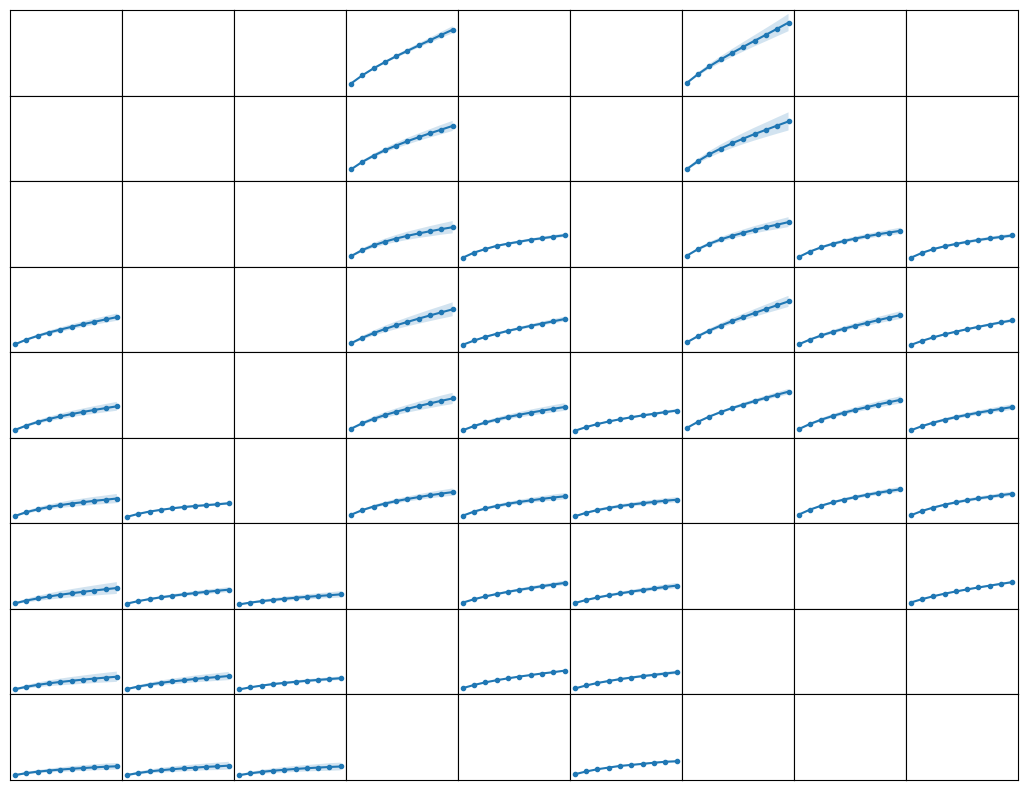

In [36]:
key = 'avg_res_ca'
fig, ax = plt.subplots(9,9, figsize=(13,10), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0, hspace=0)

x = list(range(1,11))
for nv, dv, naz, rrp in list(product(range(3), repeat=4))[:]:
    try:
        design_y, design_std = category_info[nv, dv, naz, rrp][key]
    except KeyError:
        continue

    row = 3*(2 - nv) + (2 - naz)
    col = 3*dv + rrp
    # print(row, col)

    ax[row, col].plot(x, design_y, '.-')
    ax[row, col].fill_between(x, design_y - design_std, design_y + design_std, alpha=0.2)

    for axis in ax.ravel():
        axis.tick_params(left=False, right=False, labelleft=False,
                         labelbottom=False, bottom=False)
        # axis.set_ylim(0, 1.1)

fig.savefig(os.path.join(figPath, f'{key}_4D_full.pdf'), dpi=300, 
          bbox_inches='tight', transparent=True) 

### Synaptotagmin-7

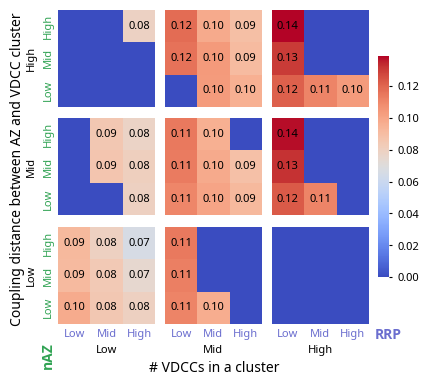

In [37]:
key = 'avg_ca_syt7_peak'

cat_plot = np.zeros(category_info.shape)
for nv, dv, naz, rrp in product(range(3), repeat=4):
    try:
        cat_plot[nv, dv, naz, rrp] = category_info[nv, dv, naz, rrp][key][0][-1]
    except KeyError:
        cat_plot[nv, dv, naz, rrp] = 0

fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=figsize_4d)
fig.subplots_adjust(wspace=0.1, hspace=0.1)

for axis in ax[-1,:]:
    axis.set_xticks(range(3))
    axis.set_xticklabels(cases, color=cpdark[5], fontsize=ticklabelsize_4d)

for axis in ax[:,0]:
    axis.set_yticks(range(3))
    axis.set_yticklabels(cases, color=cpdark[2], fontsize=ticklabelsize_4d,
                         rotation=90, ha="right", va="center")

for nv, dv in product(range(3), range(3)):
    ax[nv][dv].tick_params(axis=u'both', which=u'both',length=0)
    
    imdata = cat_plot[dv, 2-nv]
    im = ax[nv][dv].imshow(
        imdata,
        vmin=np.floor(np.min(cat_plot)) if np.min(cat_plot)>1 else np.min(cat_plot), 
        vmax=np.ceil(np.max(cat_plot)) if np.max(cat_plot)>1 else np.max(cat_plot),
        cmap='coolwarm', 
        origin='lower'
    )
    
    for i in range(3):
        for j in range(3):
            if imdata[i, j] > 0.001:
                text = ax[nv][dv].text(j, i, f'{imdata[i, j]:0.2f}', fontsize=textsize_4d,
                                       ha="center", va="center", color="black")
    if nv==2:
        ax[nv][dv].set_xlabel(cases[dv], fontsize=sublabelsize_4d)
    if dv==0:
        ax[nv][dv].set_ylabel(cases[2-nv], fontsize=sublabelsize_4d)
       
    ax[nv][dv].spines[["bottom","top","right","left"]].set_visible(False)
    
ax[-1,0].text(-1.05, -1.8, 'nAZ', size=labelsize_4d, rotation=90, color=cpdark[2], fontweight='bold')
ax[-1,-1].text(2.7, -0.96, 'RRP', size=labelsize_4d, color=cpdark[5], fontweight='bold')
ax[-1,1].text(-1, -2, '# VDCCs in a cluster', size=labelsize_4d, color=cpdark[-1])
ax[1,0].text(-2, -3.8, 'Coupling distance between AZ and VDCC cluster', 
             size=labelsize_4d, rotation=90, color=cpdark[-1])

cb = fig.colorbar(im, ax=ax.ravel().tolist(), shrink=0.7, anchor=(-0.2,0.5))
cb.outline.set_visible(False)
cb.ax.tick_params(size=2, labelsize=ticklabelsize_4d)
plt.show()

fig.savefig(os.path.join(figPath, f'{key}_4D.svg'), dpi=300, 
            bbox_inches='tight', transparent=True)

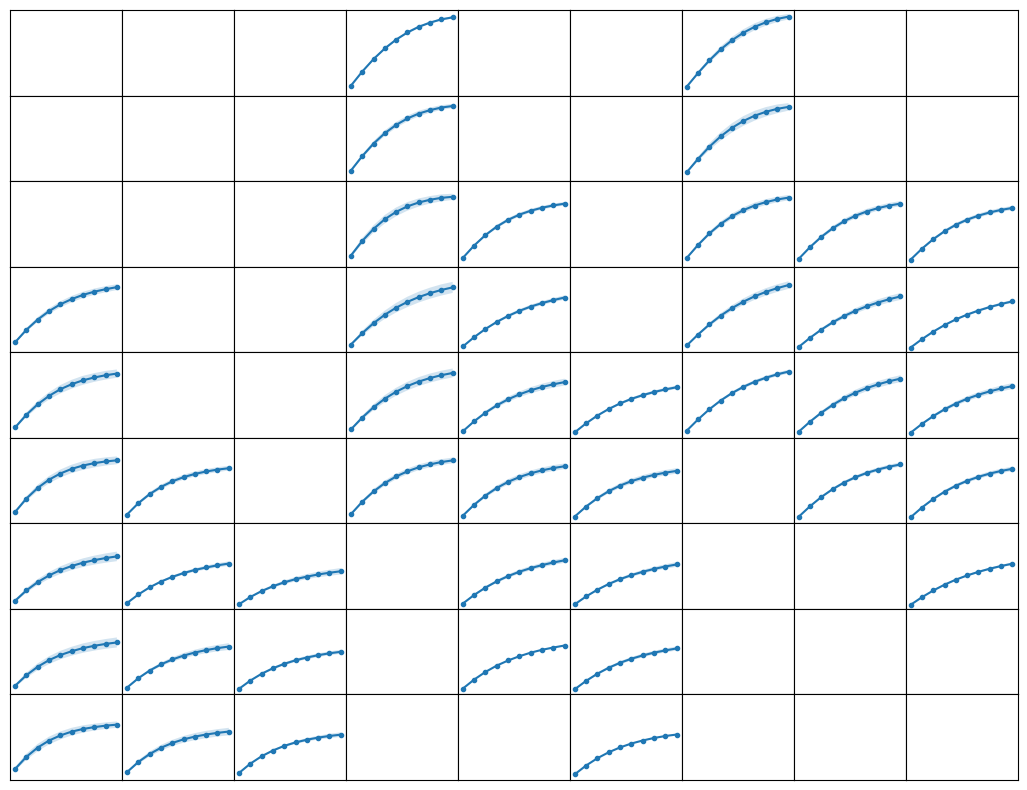

In [38]:
key = 'avg_ca_syt7_peak'
fig, ax = plt.subplots(9,9, figsize=(13,10), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0, hspace=0)

x = list(range(1,11))
for nv, dv, naz, rrp in list(product(range(3), repeat=4))[:]:
    try:
        design_y, design_std = category_info[nv, dv, naz, rrp][key]
    except KeyError:
        continue

    row = 3*(2 - nv) + (2 - naz)
    col = 3*dv + rrp
    # print(row, col)

    ax[row, col].plot(x, design_y, '.-')
    ax[row, col].fill_between(x, design_y - design_std, design_y + design_std, alpha=0.2)

    for axis in ax.ravel():
        axis.tick_params(left=False, right=False, labelleft=False,
                         labelbottom=False, bottom=False)
        # axis.set_ylim(0, 1.1)
        
plt.show()
fig.savefig(os.path.join(figPath, f'{key}_4D_full.pdf'), dpi=300, 
          bbox_inches='tight', transparent=True) 

### Synaptotagmin-1

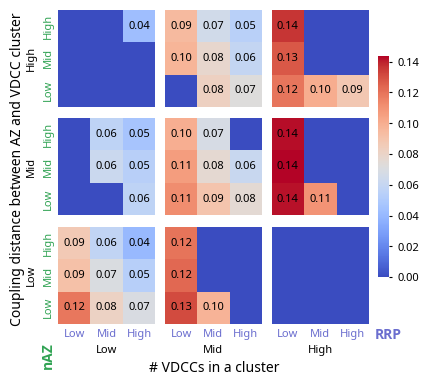

In [39]:
key = 'avg_ca_syt1_peak'

cat_plot = np.zeros(category_info.shape)
for nv, dv, naz, rrp in product(range(3), repeat=4):
    try:
        cat_plot[nv, dv, naz, rrp] = category_info[nv, dv, naz, rrp][key][0][-1]
    except KeyError:
        cat_plot[nv, dv, naz, rrp] = 0

fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=figsize_4d)
fig.subplots_adjust(wspace=0.1, hspace=0.1)

for axis in ax[-1,:]:
    axis.set_xticks(range(3))
    axis.set_xticklabels(cases, color=cpdark[5], fontsize=ticklabelsize_4d)

for axis in ax[:,0]:
    axis.set_yticks(range(3))
    axis.set_yticklabels(cases, color=cpdark[2], fontsize=ticklabelsize_4d,
                         rotation=90, ha="right", va="center")

for nv, dv in product(range(3), range(3)):
    ax[nv][dv].tick_params(axis=u'both', which=u'both',length=0)
    
    imdata = cat_plot[dv, 2-nv]
    im = ax[nv][dv].imshow(
        imdata,
        vmin=np.floor(np.min(cat_plot)) if np.min(cat_plot)>1 else np.min(cat_plot), 
        vmax=np.ceil(np.max(cat_plot)) if np.max(cat_plot)>1 else np.max(cat_plot),
        cmap='coolwarm', 
        origin='lower'
    )
    
    for i in range(3):
        for j in range(3):
            if imdata[i, j] > 0.001:
                text = ax[nv][dv].text(j, i, f'{imdata[i, j]:0.2f}', fontsize=textsize_4d,
                                       ha="center", va="center", color="black")
    if nv==2:
        ax[nv][dv].set_xlabel(cases[dv], fontsize=sublabelsize_4d)
    if dv==0:
        ax[nv][dv].set_ylabel(cases[2-nv], fontsize=sublabelsize_4d)
       
    ax[nv][dv].spines[["bottom","top","right","left"]].set_visible(False)
    
ax[-1,0].text(-1.05, -1.8, 'nAZ', size=labelsize_4d, rotation=90, color=cpdark[2], fontweight='bold')
ax[-1,-1].text(2.7, -0.96, 'RRP', size=labelsize_4d, color=cpdark[5], fontweight='bold')
ax[-1,1].text(-1, -2, '# VDCCs in a cluster', size=labelsize_4d, color=cpdark[-1])
ax[1,0].text(-2, -3.8, 'Coupling distance between AZ and VDCC cluster', 
             size=labelsize_4d, rotation=90, color=cpdark[-1])

cb = fig.colorbar(im, ax=ax.ravel().tolist(), shrink=0.7, anchor=(-0.2,0.5))
cb.outline.set_visible(False)
cb.ax.tick_params(size=2, labelsize=ticklabelsize_4d)
plt.show()

fig.savefig(os.path.join(figPath, f'{key}_4D.svg'), dpi=300, 
            bbox_inches='tight', transparent=True)

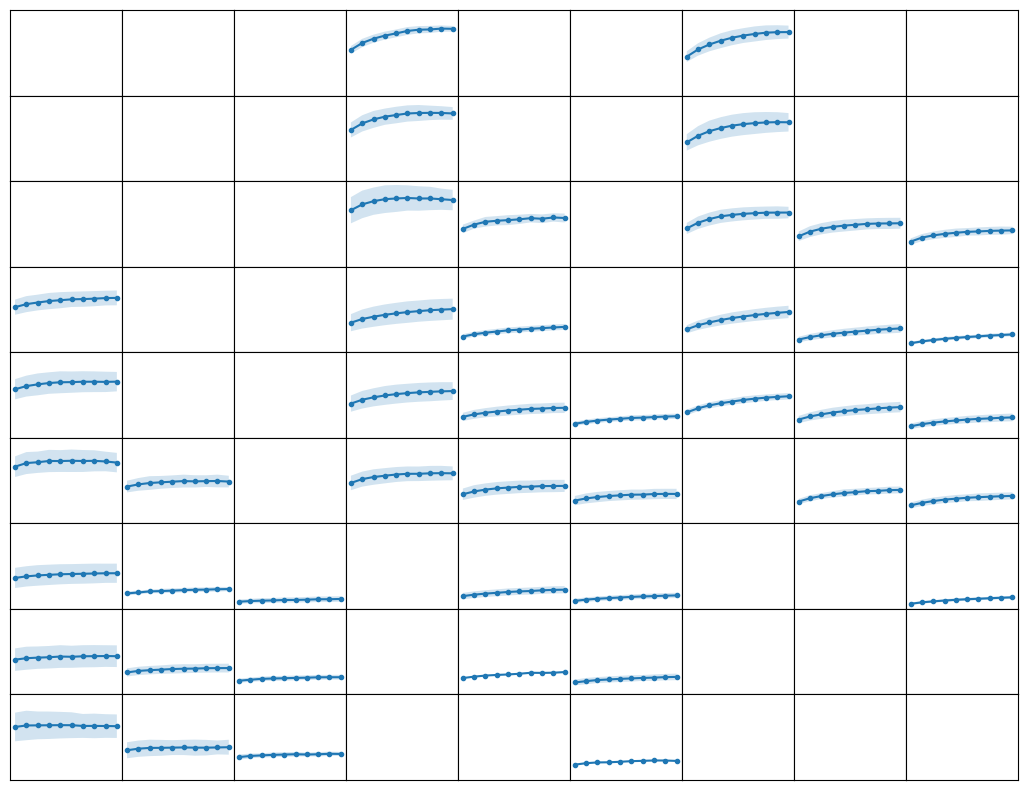

In [40]:
key = 'avg_ca_syt1_peak'

fig, ax = plt.subplots(9,9, figsize=(13,10), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0, hspace=0)

x = list(range(1,11))
for nv, dv, naz, rrp in list(product(range(3), repeat=4))[:]:
    try:
        design_y, design_std = category_info[nv, dv, naz, rrp][key]
    except KeyError:
        continue

    row = 3*(2 - nv) + (2 - naz)
    col = 3*dv + rrp
    # print(row, col)

    ax[row, col].plot(x, design_y, '.-')
    ax[row, col].fill_between(x, design_y - design_std, design_y + design_std, alpha=0.2)

    for axis in ax.ravel():
        axis.tick_params(left=False, right=False, labelleft=False,
                         labelbottom=False, bottom=False)
        # axis.set_ylim(0, 1.1)
        
plt.show()
fig.savefig(os.path.join(figPath, f'{key}_4D_full.pdf'), dpi=300,
            bbox_inches='tight', transparent=True) 

### Representative plots (lineplots)

In [41]:
keys = ['avg_ca_peak', 'avg_res_ca', 'avg_ca_syt7_peak', 'avg_ca_syt1_peak']

y_data = {}
for nv, dv, naz, rrp in product(range(3), repeat=4):
    try:
        design = category_info[nv, dv, naz, rrp]['rep_design_median']
    except KeyError as e:
        # print(f'Could not find design for {cdiv[nv]}, {cdiv[dv]}, {cdiv[naz]}, {cdiv[rrp]}')
        # print(e)
        continue

    ## Read data from 'CaConc.dat' of the design
    data = pd.read_csv(os.path.join(dataPath, 'control', design, 'CaConc.dat'), sep='\t',
                        usecols=range(int(getSimInfo(design, 'nAZ', skip=0))+1))
    data['mean'] = np.mean(data.iloc[:,1:], axis=1)
    # print(design, '\n', data)
    
    ## Detect peaks and ensure all 10 peaks are detected
    idx = detect_peaks(data['mean'], mph=1, mpd=200, threshold=0, edge='rising', show=False)
    assert len(idx) == 10, f'Peak detecction failed for design {design}'

    ca_peak = [data.loc[id,'mean'] for id in idx]
    ca_res = [np.mean(data.loc[id+100:id+300,'mean']) for id in idx]
            
    data_median = pd.read_csv(os.path.join(dataPath, 'control', design, 'result.dat'),
                              usecols=['Pr', 'Rel'], sep='\t')

    ca_syt7_peak, ca_syt1_peak = get_ca_syt(design)

    label=f'{cdiv[nv]},  {cdiv[dv]},  {cdiv[naz]},  {cdiv[rrp]}'
    y_data[label] = {
        'avg_ca_peak': ca_peak, 
        'avg_res_ca': ca_res,
        'avg_ca_syt7_peak': ca_syt7_peak,
        'avg_ca_syt1_peak': ca_syt1_peak,
        'facil': data_median['Rel']*data_median['Pr'][0]/data_median['Pr']/data_median['Rel'][0]
    }
    # break #####################
y_sorted = [list(y['facil']) for y in y_data.values()]
y_sorted.sort(key = lambda x: x[-1], reverse=True)
# print(y_sorted)

des_sorted = []
for yy in y_sorted:
    des_sorted.append([k for k, v in y_data.items() if list(v['facil']) == yy][0])

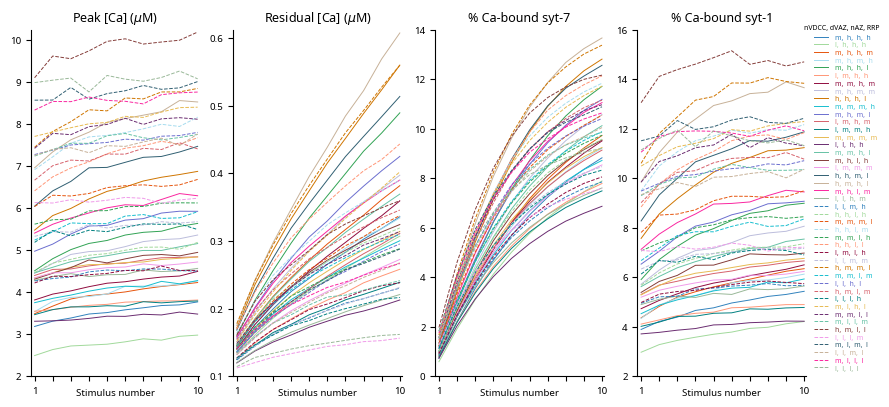

In [43]:
title_text = {'avg_ca_peak': r'Peak [Ca] ($\mu$M)', 
              'avg_res_ca': r'Residual [Ca] ($\mu$M)',
              'avg_ca_syt7_peak': '% Ca-bound syt-7',
              'avg_ca_syt1_peak': '% Ca-bound syt-1'}

marker = ['-','--']
n_plots = len(keys)
fig, ax = plt.subplots(1,n_plots, sharex=True, figsize=(2.5*n_plots,4.5))

for i, key in enumerate(keys):
    y_sorted = [list(y_data[des][key]) for des in des_sorted]

    x = list(range(1,11))
    for j,y in enumerate(y_sorted):
        # print(y)
        # label = [k for k, v in y_data.items() if list(v) == list(y)][0]
        if 'ca_syt' in key: y = np.array(y)*100
        ax[i].plot(x, y, label=des_sorted[j],
                   # marker='.', markersize=4,
                   linestyle=marker[j//22],
                   linewidth=0.7, color=cpall[j%22])

    ax[i].set_xlim(0.8,10.1)
    ax[i].set_xlabel('Stimulus number', labelpad=-5, fontsize=7)
    ax[i].spines[['right', 'top']].set_visible(False)

    ax[i].set_title(title_text[key], fontsize=9)
    # ax[i].set_xticks([1,4,7,10], [1,4,7,10], fontsize=10)
    ax[i].set_xticks(range(1,11), [1]+['']*8+[10], fontsize=7)
    ax[i].tick_params(axis='y', labelsize=7)
    
ax[-1].legend(frameon=False, loc='center left', bbox_to_anchor=(1.01, 0.5), 
              fontsize=5, handletextpad=1, handlelength=2, 
              labelspacing=0.1, labelcolor='linecolor')

ax[-1].text(10, 16, 'nVDCC, dVAZ, nAZ, RRP', size=5, color=cpdark[-1])
ax[0].set_ylim(2,10.25)
ax[1].set_ylim(0.1,0.612)
ax[2].set_ylim(0,14)
ax[3].set_ylim(2,16)

plt.show()
fig.savefig(os.path.join(figPath, 'rep_ca_lineplot.svg'), dpi=300, 
            bbox_inches='tight', transparent=True)